In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import numpy as np
import jax.numpy as jnp

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.grid'] = True
mpl.rcParams['axes.xmargin'] = 0
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['legend.frameon'] = False
mpl.rcParams['savefig.bbox'] = 'tight'

import jaxsp as jsp

from scipy import constants as const

import sys
sys.path.insert(0, "/home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses")

import Stellar_sim_funcs as SSF
import importlib
importlib.reload(SSF)


from scipy.interpolate import interp1d

from collections import defaultdict

from jaxsp.constants import h, om, hbar, Msun, GN, c, m22

from collections import defaultdict

from numpy.polynomial.legendre import leggauss
from scipy.special import sph_harm



An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [2]:
m22 = 1
u = jsp.set_schroedinger_units(m22)

G = GN.value * (u.from_cm**3) / (u.from_g * u.from_s**2)

# $\rho(r, \theta, \phi) = \frac{1}{r}(1 + \sin{\theta} \cos{\phi})$

### Take the angle-average value of the function for each r
### $\rho(r) = \int_{0}^{2\pi}d\phi \int_{0}^{\pi} \rho(r, \theta, \phi) * \sin{\theta}d\theta$
### $\therefore \rho(r) = \frac{1}{r}$

(1000, 24, 47)


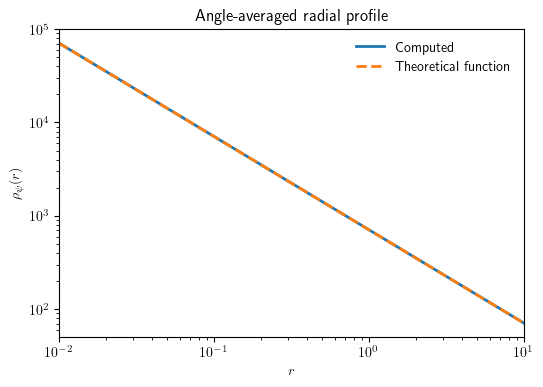

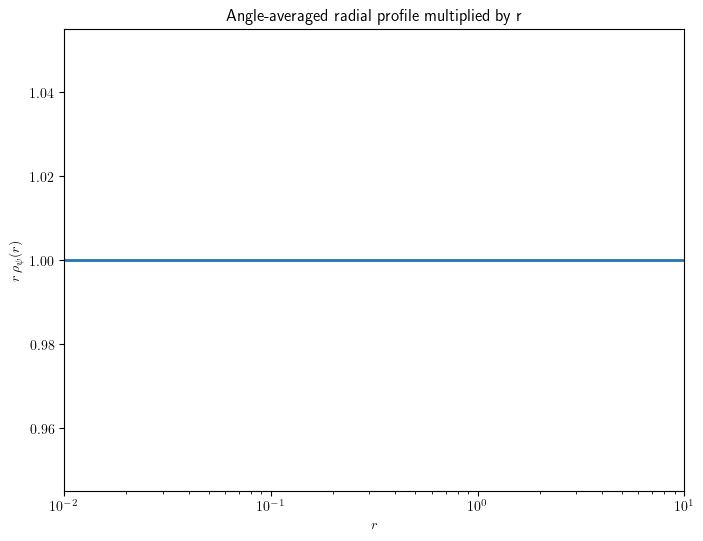

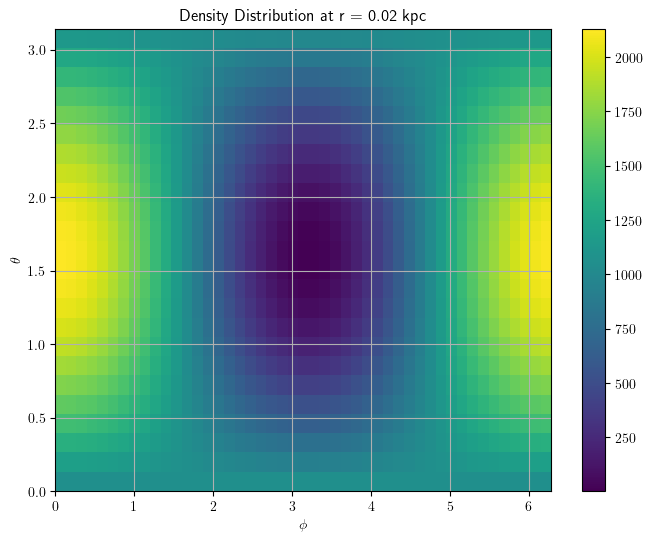

In [3]:
l = np.array([23])

L = int(l.max()) + 1

# McEwen–Wiaux–style equiangular grid
n_theta = L
n_phi   = 2 * L - 1

# Generate theta values
i = np.arange(n_theta)
theta = (np.pi * (2 * i + 1)) / (2 * L - 1)
    
# Generate phi values
j = np.arange(n_phi)
phi = (2 * np.pi * j) / (2 * L - 1)           

Theta, Phi = jnp.meshgrid(theta, phi, indexing="ij")  # both (n_theta, n_phi)

r_min = 0.01 * u.from_Kpc
r_max = 10 * u.from_Kpc


r = np.logspace(np.log10(r_min), np.log10(r_max), 1000)

#Function is rho(r, theta, phi) = 1/r * (1 + sin(theta) * cos(phi))

# Construct ρ(r, θ, φ)

rho_rtp = (1 / r[:, None, None]) * (1 + jnp.sin(Theta)[None, :, :] * jnp.cos(Phi)[None, :, :])  # (Nr, n_theta, n_phi)

print(rho_rtp.shape)

# #Compute angle-averaged radial profile

# Quadrature weights on the MW equiangular grid
dtheta = 2 * jnp.pi / n_phi
dphi   = 2 * jnp.pi / n_phi

w_theta = jnp.sin(theta) * dtheta            # (n_theta,)
w_phi   = jnp.ones_like(phi) * dphi          # (n_phi,)

w = w_theta[:, None] * w_phi[None, :]  # (n_theta, n_phi)
w = w[None, :, :]

norm = w.sum()                      # ≈ 4π

# Angle-averaged radial profile ρ_ψ(r)
# Contract over (θ, φ) with weights, then normalise.
rho_psi_r = jnp.sum(rho_rtp * w, axis=(1, 2)) / norm  # (Nr,)


plt.figure(figsize=(6, 4))
plt.plot(r * u.to_Kpc, rho_psi_r * u.to_Msun / u.to_Kpc**3, label = 'Computed')
plt.plot(r * u.to_Kpc, (1/r) * u.to_Msun / u.to_Kpc**3, '--', label = 'Theoretical function')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"$r$")
plt.ylabel(r"$\rho_\psi(r)$")
plt.title("Angle-averaged radial profile")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(r * u.to_Kpc, round(rho_psi_r * r, 5))
plt.xscale('log')
plt.xlabel(r"$r$")
plt.ylabel(r"$r \, \rho_\psi(r)$")
plt.title("Angle-averaged radial profile multiplied by r")
plt.grid()
plt.show()


plt.figure(figsize=(8, 6))
i = 100
plt.imshow(rho_rtp[i,:,:].real, extent=(0, 2 * np.pi, 0, np.pi), aspect='auto')
plt.colorbar()
plt.xlabel(r'$\phi$')
plt.ylabel(r'$\theta$')
plt.title('Density Distribution at r = %.2f kpc' % (r[i] * u.to_Kpc))
plt.show()



# Computing SHT $\rho(r, \theta, \phi) = \sum_{l,m}\rho_{l,m}(r)Y_{l,m}(\theta, \phi)$

### Only Non zero coefficients are for $Y_{0,0}, Y_{1,1}, Y_{1,-1}$

### From calculations get: 

### $\rho_{00} = \frac{\sqrt{4\pi}}{r}$
### $\rho_{1, -1} = \sqrt{\frac{2\pi}{3}}\frac{1}{r}$
### $\rho_{1, 1} = -\sqrt{\frac{2\pi}{3}}\frac{1}{r}$

### $\therefore$
### $\log{\rho_{0, 0}} = \frac{1}{2}\log{4\pi} - \log{r}$. Intercept = 0.5496
### $\log{\rho_{1, -1}} = \frac{1}{2}\log{\frac{2\pi}{3}} - \log{r}$. Intercept = 0.1605

### Note: the gradients and interepts wont be exact as we are sampling the function at a finite number of $\theta$ and $\phi$ coordinates
### Therefore, also wont just be that $Y_{0,0}$, $Y_{1,-1}$, $Y_{1,1}$ are the only non zero spherical harmonics as the function wont exactly
### equal the linear sum of only these three.


(1000, 24, 47)


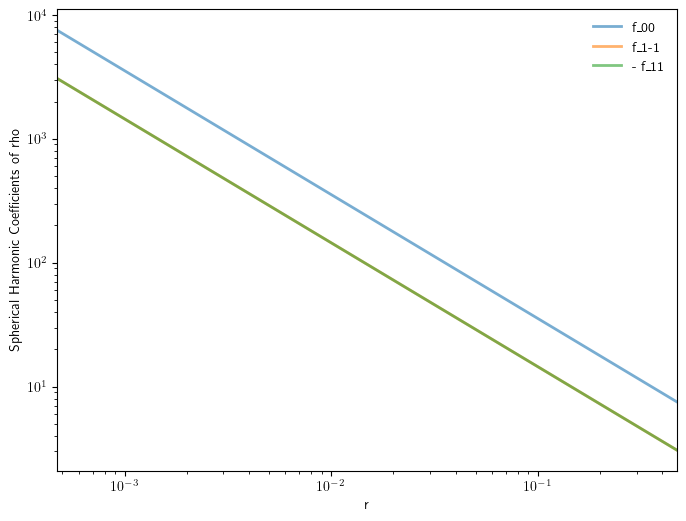

Slope and intercept of log-log plot of f_00 vs r:  (-0.9999999999999981+1.1522002074557364e-20j) (0.5496049320110482+2.663534944314513e-21j)
Slope and intercept of log-log plot of f_11 vs r:  (-0.9999999999999979+1.199326396359387e-19j) (0.16052930681922656-7.130289690839419e-17j)
Slope and intercept of log-log plot of f_1-1 vs r:  (-0.999999999999998-2.43505494608677e-20j) (0.16052930681922634+4.323988425722319e-17j)
(l, m) = (0, 0)
(l, m) = (1, -1)
(l, m) = (1, 0)
(l, m) = (1, 1)
Skipping as l > 1
Skipping as l > 1
Skipping as l > 1
Skipping as l > 1
Skipping as l > 1
Skipping as l > 1
Skipping as l > 1
Skipping as l > 1
Skipping as l > 1
Skipping as l > 1
Skipping as l > 1
Skipping as l > 1
Skipping as l > 1
Skipping as l > 1
Skipping as l > 1
Skipping as l > 1
Skipping as l > 1
Skipping as l > 1
Skipping as l > 1
Skipping as l > 1
Skipping as l > 1
Skipping as l > 1
Skipping as l > 1
Skipping as l > 1
Skipping as l > 1
Skipping as l > 1
Skipping as l > 1
Skipping as l > 1
Skipping 

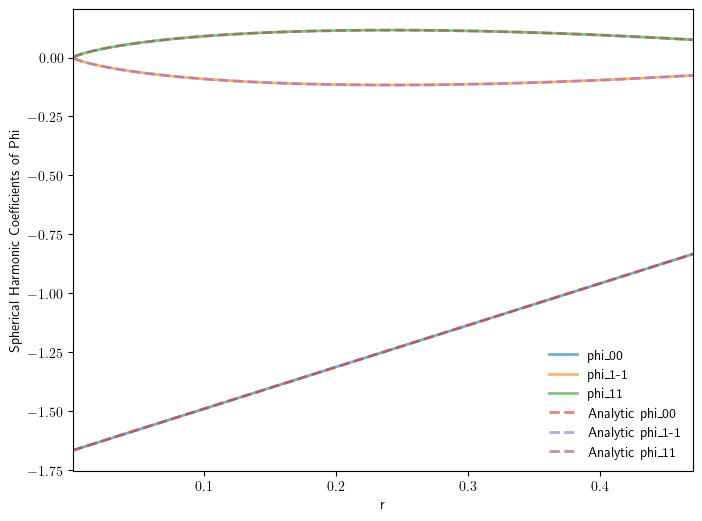

(1000, 24, 47)


In [4]:
importlib.reload(SSF)

Phi_rtp, Phi_r_dt, phi_lm = SSF.Calculating_Phi_from_rho_in_3d_Unit_Test(l, rho_rtp, r, dtheta, dphi, theta, phi)

### Performing SHT, then integration given in http://arxiv.org/abs/2011.13141, then inverse SHT

### $\Phi(r, \theta, \phi) = -4\pi G(R_{max} - \frac{1}{2}r - \frac{1}{2}\frac{R_{min}^2}{r}) -\frac{4\pi G}{3}(r\ln{\frac{R_{max}}{r}} + \frac{1}{3}r - \frac{1}{3}\frac{R_{min}^3}{r^2})\sin{\theta}\cos{\phi}$

### Performing angle average

### $\Phi(r) = -4\pi G(R_{max} - \frac{1}{2}r - \frac{1}{2}\frac{R_{min}^2}{r})$

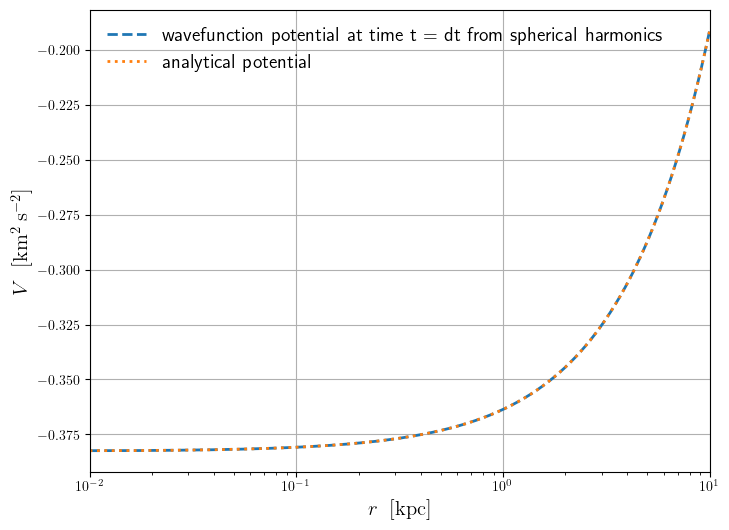

In [5]:

Phi_r_maths = -4*np.pi*G*(r_max - 1/2*r - 1/2 * r_min**2 / r)

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(r * u.to_Kpc, Phi_r_dt * u.to_kms**2, label='wavefunction potential at time t = dt from spherical harmonics', lw=2, ls='--')
ax.plot(r * u.to_Kpc, Phi_r_maths * u.to_kms**2, label='analytical potential', lw=2, ls=':')
ax.set_xscale('log')
ax.set_ylabel(r"$V \;\;\mathrm{[km^2 \;s^{-2}]}$", fontsize = 15)
ax.set_xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 15)
plt.legend(fontsize = 14)
plt.show()
